# MSc Dissertation: Heart Disease Prediction
### Author: LOKANADHA APPACHULA

**Models:** Logistic Regression | Decision Tree | Random Forest | SVM | XGBoost  
**Techniques:** GridSearchCV | 5-Fold CV | ROC-AUC | Feature Importance  
**Dataset:** Cardiovascular Disease Dataset (70,000 patients)

---
## How to Use This Notebook
1. Click **Runtime → Run All** OR run each cell top to bottom  
2. In **Step 2**, click **Choose Files** to upload `cardio_train.csv`  
3. All plots show inline — no downloads needed until the end  
4. At the end, model `.pkl` files download automatically for the Streamlit app


## Step 1 — Install & Import Libraries
Google Colab already has most libraries. We confirm XGBoost is available and import everything needed.

In [1]:
# Install XGBoost (already in Colab but good to confirm version)
!pip install xgboost --quiet
print("Install check done!")

Install check done!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import time
warnings.filterwarnings("ignore")

# Scikit-learn
from sklearn.model_selection  import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing    import StandardScaler
from sklearn.metrics          import (accuracy_score, precision_score, recall_score,
                                      f1_score, roc_auc_score, roc_curve,
                                      confusion_matrix, ConfusionMatrixDisplay,
                                      classification_report)
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.svm              import SVC
from xgboost                  import XGBClassifier

import sklearn, xgboost
print("All libraries imported successfully!")
print("Scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)

All libraries imported successfully!
Scikit-learn: 1.6.1
XGBoost: 3.2.0


## Step 2 — Upload Dataset
Run this cell and click **Choose Files** to upload `cardio_train.csv`.  
The dataset has **70,000 rows** and **13 columns**, separated by semicolons (`;`).

In [4]:
from google.colab import files

print("Click 'Choose Files' below and select cardio_train.csv ...")
uploaded = files.upload()

# Load the uploaded file
df = pd.read_csv("cardio_train.csv", sep=";")

print(f"\nDataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
print("\nFirst 5 rows:")
df.head()

Click 'Choose Files' below and select cardio_train.csv ...


Saving cardio_train.csv to cardio_train (1).csv

Dataset loaded: 70,000 rows x 13 columns
Columns: ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

First 5 rows:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## Step 3 — Data Cleaning
- Drop `id` column (just a row identifier, not a feature)  
- Convert `age` from **days → years** (original stores age in days)  
- Check for **missing values**  
- Remove **outliers** — physiologically impossible blood pressure, height, and weight values  

**Why remove outliers?**  
Values like systolic BP of 1000 mmHg are data entry errors. Keeping them distorts model training.

In [5]:
# Drop ID column — not a meaningful feature
df = df.drop("id", axis=1)

# Convert age: days -> years  (divide by 365.25 to account for leap years)
df["age"] = (df["age"] / 365.25).round(1)
print(f"Age range: {df['age'].min():.1f} to {df['age'].max():.1f} years")

# Check missing values
print(f"\nMissing values: {df.isnull().sum().sum()} (should be 0)")

# Remove outliers using medical reference ranges
before = len(df)
df = df[(df["ap_hi"]  > 50)  & (df["ap_hi"]  < 250)]   # Systolic BP: 50-250 mmHg
df = df[(df["ap_lo"]  > 30)  & (df["ap_lo"]  < 150)]   # Diastolic BP: 30-150 mmHg
df = df[(df["height"] > 100) & (df["height"] < 250)]   # Height: 100-250 cm
df = df[(df["weight"] > 30)  & (df["weight"] < 200)]   # Weight: 30-200 kg
df = df[df["ap_hi"] >= df["ap_lo"]]                    # Systolic must be >= Diastolic

after = len(df)
print(f"\nOutliers removed: {before - after:,} rows")
print(f"Remaining rows:   {after:,}")

# Summary statistics
df.describe().round(2)

Age range: 29.6 to 64.9 years

Missing values: 0 (should be 0)

Outliers removed: 1,374 rows
Remaining rows:   68,626


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,68626.00,68626.00,68626.00,68626.00,68626.00,68626.00,68626.00,68626.00,68626.00,68626.00,68626.0,68626.00
mean,53.29,1.35,164.40,74.12,126.67,81.30,1.36,1.23,0.09,0.05,0.8,0.49
std,6.76,0.48,7.96,14.29,16.68,9.42,0.68,0.57,0.28,0.22,0.4,0.50
min,29.60,1.00,104.00,31.00,60.00,40.00,1.00,1.00,0.00,0.00,0.0,0.00
25%,48.30,1.00,159.00,65.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.00
50%,53.90,1.00,165.00,72.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.00
75%,58.40,2.00,170.00,82.00,140.00,90.00,2.00,1.00,0.00,0.00,1.0,1.00
max,64.90,2.00,207.00,183.00,240.00,140.00,3.00,3.00,1.00,1.00,1.0,1.00


## Step 4 — Feature Engineering
We add **BMI (Body Mass Index)** as a derived feature.

> **BMI = weight (kg) / height (m)²**

BMI is a standard cardiovascular risk indicator:
- Normal: 18.5–24.9 | Overweight: 25–29.9 | Obese: ≥ 30

In [6]:
# Compute BMI from height and weight
df["bmi"] = (df["weight"] / ((df["height"] / 100) ** 2)).round(2)

print(f"BMI range: {df['bmi'].min():.1f} to {df['bmi'].max():.1f}")
print(f"Mean BMI:  {df['bmi'].mean():.1f}")
print(f"\nFinal columns ({len(df.columns)}): {list(df.columns)}")

BMI range: 10.7 to 152.6
Mean BMI:  27.5

Final columns (13): ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'bmi']


## Step 5 — Exploratory Data Analysis (EDA)
We analyse every column individually — distributions, relationships with the target, and correlations.

### 5a — Target Variable: Heart Disease Distribution
An imbalanced dataset leads to biased classifiers — we check the class balance here.

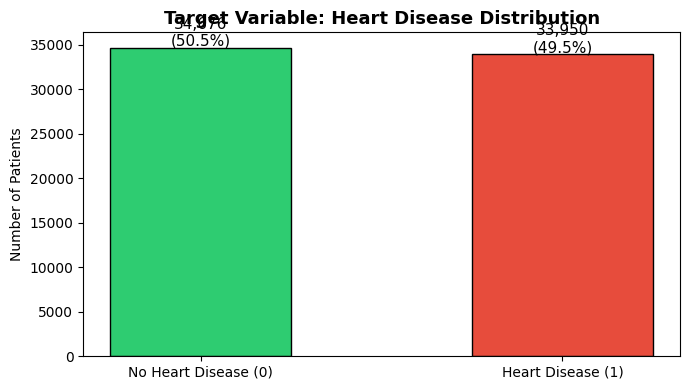

Class 0 (No Disease): 34,676 | Class 1 (Disease): 33,950


In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = df["cardio"].value_counts()
bars = ax.bar(["No Heart Disease (0)", "Heart Disease (1)"],
               counts.values, color=["#2ecc71", "#e74c3c"], edgecolor="black", width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{val:,}\n({val/len(df)*100:.1f}%)", ha="center", fontsize=11)
ax.set_title("Target Variable: Heart Disease Distribution", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Patients")
plt.tight_layout(); plt.show()
print(f"Class 0 (No Disease): {counts[0]:,} | Class 1 (Disease): {counts[1]:,}")

### 5b — Age Distribution by Outcome
Age is one of the strongest cardiovascular risk factors. Risk increases significantly after 50.

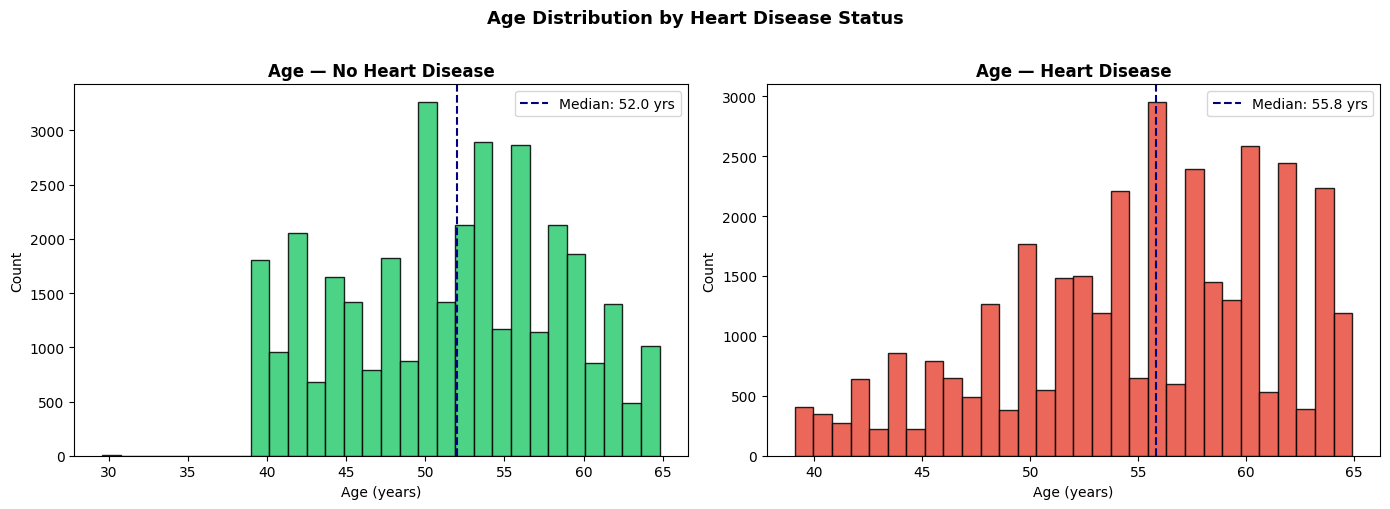

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, label, colour, title in zip(axes, [0, 1], ["#2ecc71", "#e74c3c"],
                                     ["No Heart Disease", "Heart Disease"]):
    ax.hist(df[df["cardio"] == label]["age"], bins=30, color=colour, edgecolor="black", alpha=0.85)
    med = df[df["cardio"] == label]["age"].median()
    ax.axvline(med, color="navy", linestyle="--", linewidth=1.5, label=f"Median: {med:.1f} yrs")
    ax.set_title(f"Age — {title}", fontweight="bold")
    ax.set_xlabel("Age (years)"); ax.set_ylabel("Count"); ax.legend()
plt.suptitle("Age Distribution by Heart Disease Status", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

### 5c — Gender Distribution
`gender` is encoded as 1 = Female, 2 = Male in this dataset.

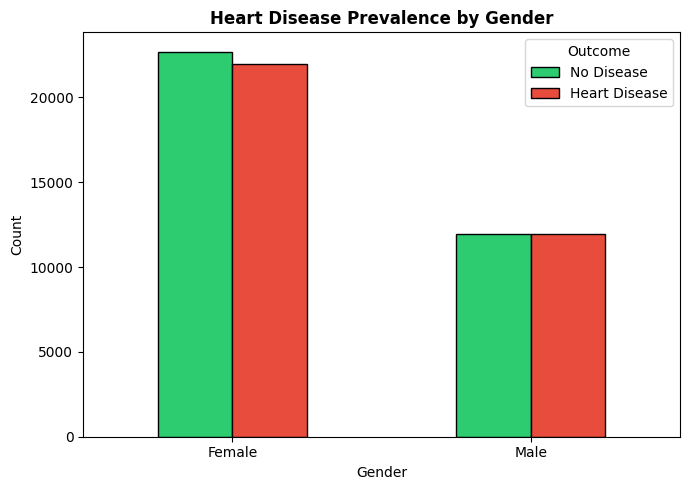

        No Disease  Heart Disease
Female       22704          21997
Male         11972          11953


In [9]:
gender_cardio = df.groupby(["gender", "cardio"]).size().unstack()
gender_cardio.index = ["Female", "Male"]
gender_cardio.columns = ["No Disease", "Heart Disease"]
fig, ax = plt.subplots(figsize=(7, 5))
gender_cardio.plot(kind="bar", ax=ax, color=["#2ecc71", "#e74c3c"], edgecolor="black", rot=0)
ax.set_title("Heart Disease Prevalence by Gender", fontsize=12, fontweight="bold")
ax.set_xlabel("Gender"); ax.set_ylabel("Count"); ax.legend(title="Outcome")
plt.tight_layout(); plt.show()
print(gender_cardio)

### 5d — Blood Pressure Distribution
Hypertension is the **#1 risk factor** for cardiovascular disease.
- Normal systolic: < 120 mmHg | Stage 2 Hypertension: ≥ 140 mmHg

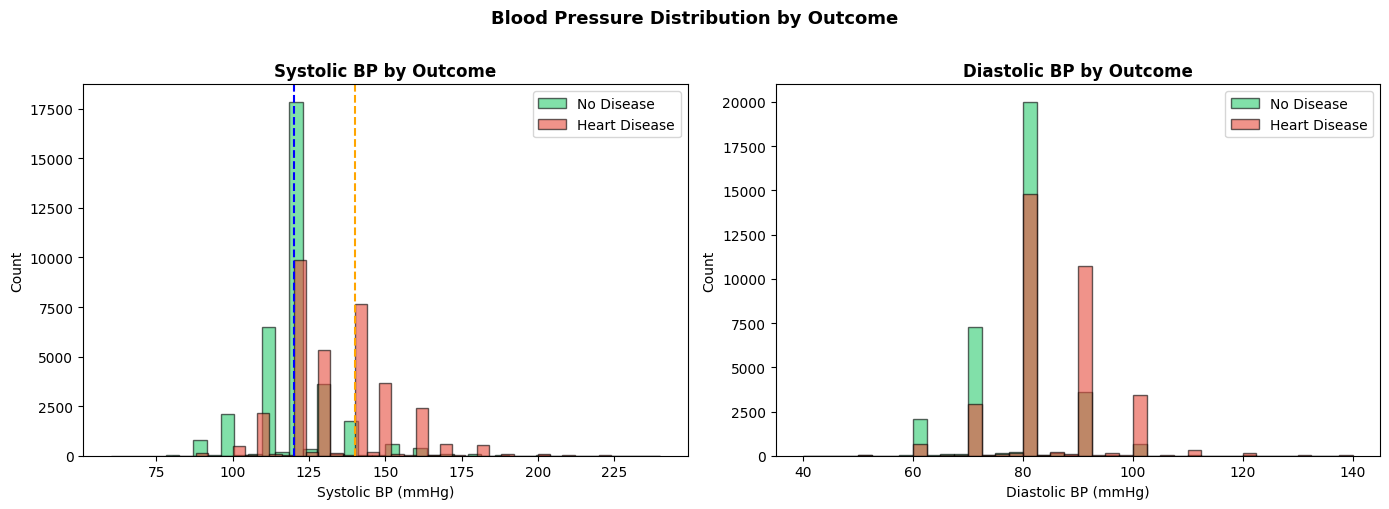

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes, ["ap_hi", "ap_lo"], ["Systolic BP", "Diastolic BP"]):
    for label, colour, name in zip([0,1],["#2ecc71","#e74c3c"],["No Disease","Heart Disease"]):
        ax.hist(df[df["cardio"]==label][col], bins=40, color=colour, alpha=0.6, edgecolor="black", label=name)
    ax.set_title(f"{title} by Outcome", fontweight="bold")
    ax.set_xlabel(f"{title} (mmHg)"); ax.set_ylabel("Count"); ax.legend()
axes[0].axvline(120, color="blue",   linestyle="--", linewidth=1.5, label="Normal 120")
axes[0].axvline(140, color="orange", linestyle="--", linewidth=1.5, label="Hypertension 140")
plt.suptitle("Blood Pressure Distribution by Outcome", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

### 5e — Cholesterol & Glucose Levels
Encoded as: **1=Normal, 2=Above Normal, 3=Well Above Normal**  
Higher levels = greater cardiovascular risk.

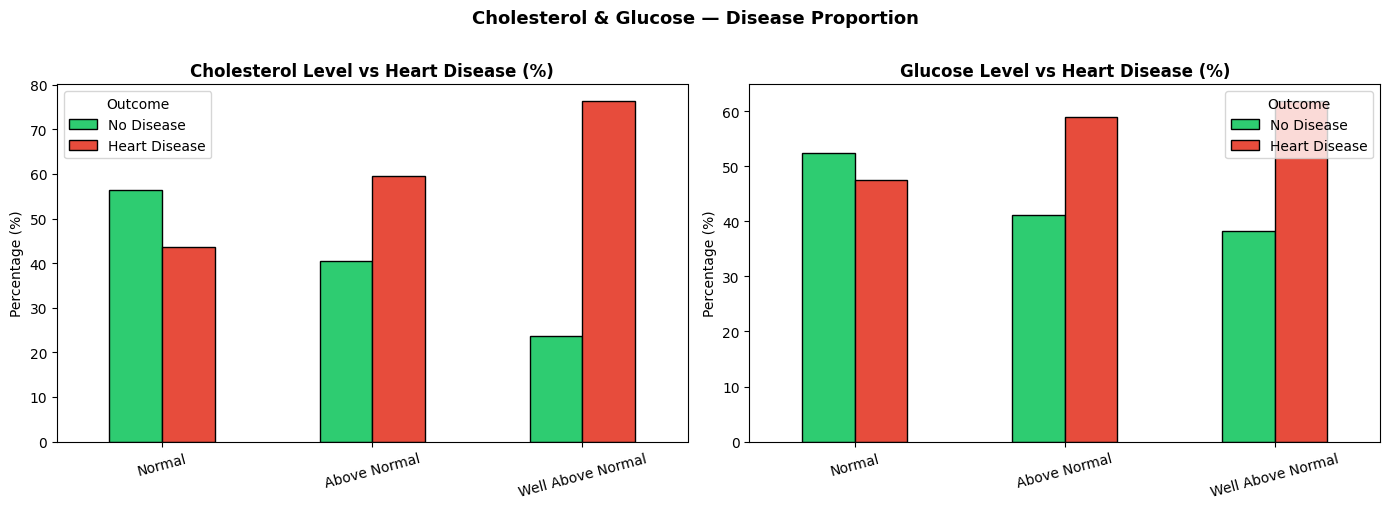

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, lbl in zip(axes, ["cholesterol", "gluc"], ["Cholesterol", "Glucose"]):
    ct = pd.crosstab(df[col], df["cardio"], normalize="index") * 100
    ct.index = ["Normal", "Above Normal", "Well Above Normal"]
    ct.columns = ["No Disease", "Heart Disease"]
    ct.plot(kind="bar", ax=ax, color=["#2ecc71", "#e74c3c"], edgecolor="black", rot=15)
    ax.set_title(f"{lbl} Level vs Heart Disease (%)", fontweight="bold")
    ax.set_ylabel("Percentage (%)"); ax.legend(title="Outcome")
plt.suptitle("Cholesterol & Glucose — Disease Proportion", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

### 5f — Lifestyle Factors
`smoke`, `alco`, `active` are binary (0=No, 1=Yes).  
Physical inactivity and smoking are established cardiovascular risk factors.

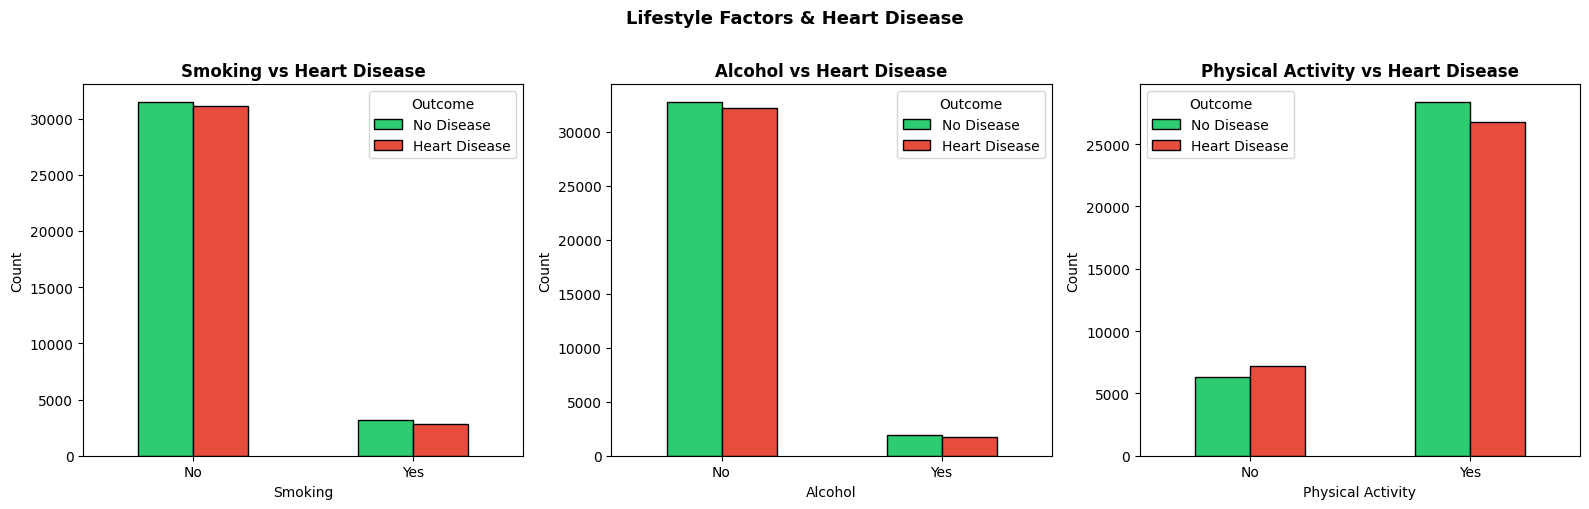

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, lbl in zip(axes, ["smoke","alco","active"], ["Smoking","Alcohol","Physical Activity"]):
    ct = df.groupby([col,"cardio"]).size().unstack(fill_value=0)
    ct.index = ["No","Yes"]; ct.columns = ["No Disease","Heart Disease"]
    ct.plot(kind="bar", ax=ax, color=["#2ecc71","#e74c3c"], edgecolor="black", rot=0)
    ax.set_title(f"{lbl} vs Heart Disease", fontweight="bold")
    ax.set_xlabel(lbl); ax.set_ylabel("Count"); ax.legend(title="Outcome")
plt.suptitle("Lifestyle Factors & Heart Disease", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

### 5g — BMI Distribution
Overweight (≥25) and obese (≥30) patients face significantly higher cardiovascular risk.

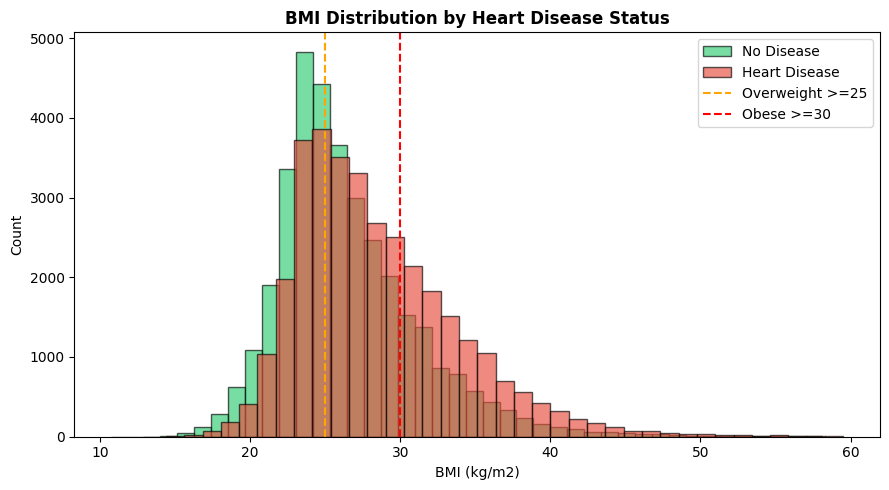

Mean BMI - No Disease: 26.5
Mean BMI - Disease:    28.5


In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
for label, colour, name in zip([0,1],["#2ecc71","#e74c3c"],["No Disease","Heart Disease"]):
    ax.hist(df[(df["cardio"]==label)&(df["bmi"]<60)]["bmi"], bins=40,
            color=colour, alpha=0.65, edgecolor="black", label=name)
ax.axvline(25, color="orange", linestyle="--", linewidth=1.5, label="Overweight >=25")
ax.axvline(30, color="red",    linestyle="--", linewidth=1.5, label="Obese >=30")
ax.set_title("BMI Distribution by Heart Disease Status", fontsize=12, fontweight="bold")
ax.set_xlabel("BMI (kg/m2)"); ax.set_ylabel("Count"); ax.legend()
plt.tight_layout(); plt.show()
print(f"Mean BMI - No Disease: {df[df['cardio']==0]['bmi'].mean():.1f}")
print(f"Mean BMI - Disease:    {df[df['cardio']==1]['bmi'].mean():.1f}")

### 5h — Correlation Heatmap
Pearson correlation shows which features are most related to the target (`cardio`) and to each other.  
Values close to +1 or -1 indicate strong relationships.

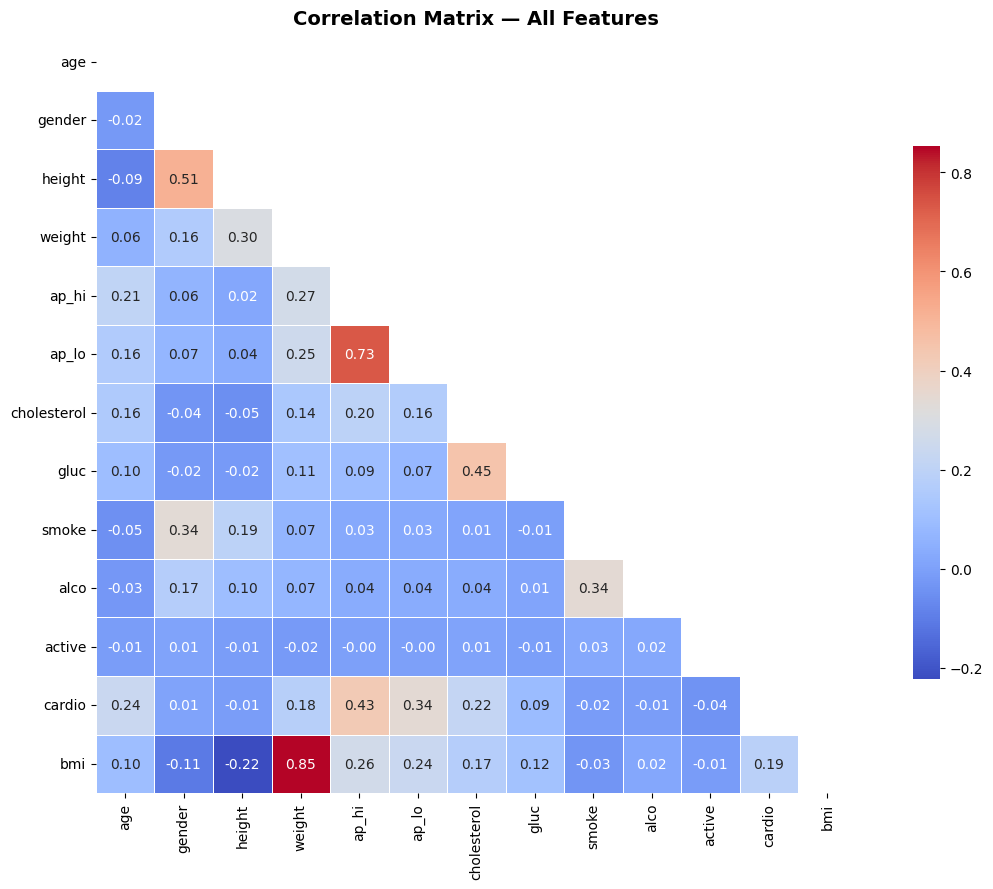


Correlation with target (cardio):
cardio         1.000
ap_hi          0.428
ap_lo          0.341
age            0.239
cholesterol    0.221
bmi            0.187
weight         0.180
gluc           0.090
gender         0.007
alco          -0.009
height        -0.012
smoke         -0.016
active        -0.038
Name: cardio, dtype: float64


In [14]:
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # Show lower triangle only
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.7})
plt.title("Correlation Matrix — All Features", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()
print("\nCorrelation with target (cardio):")
print(corr["cardio"].sort_values(ascending=False).round(3))

### 5i — Boxplots: Key Features by Outcome
A clear median separation between the two boxes indicates the feature is a good discriminator.

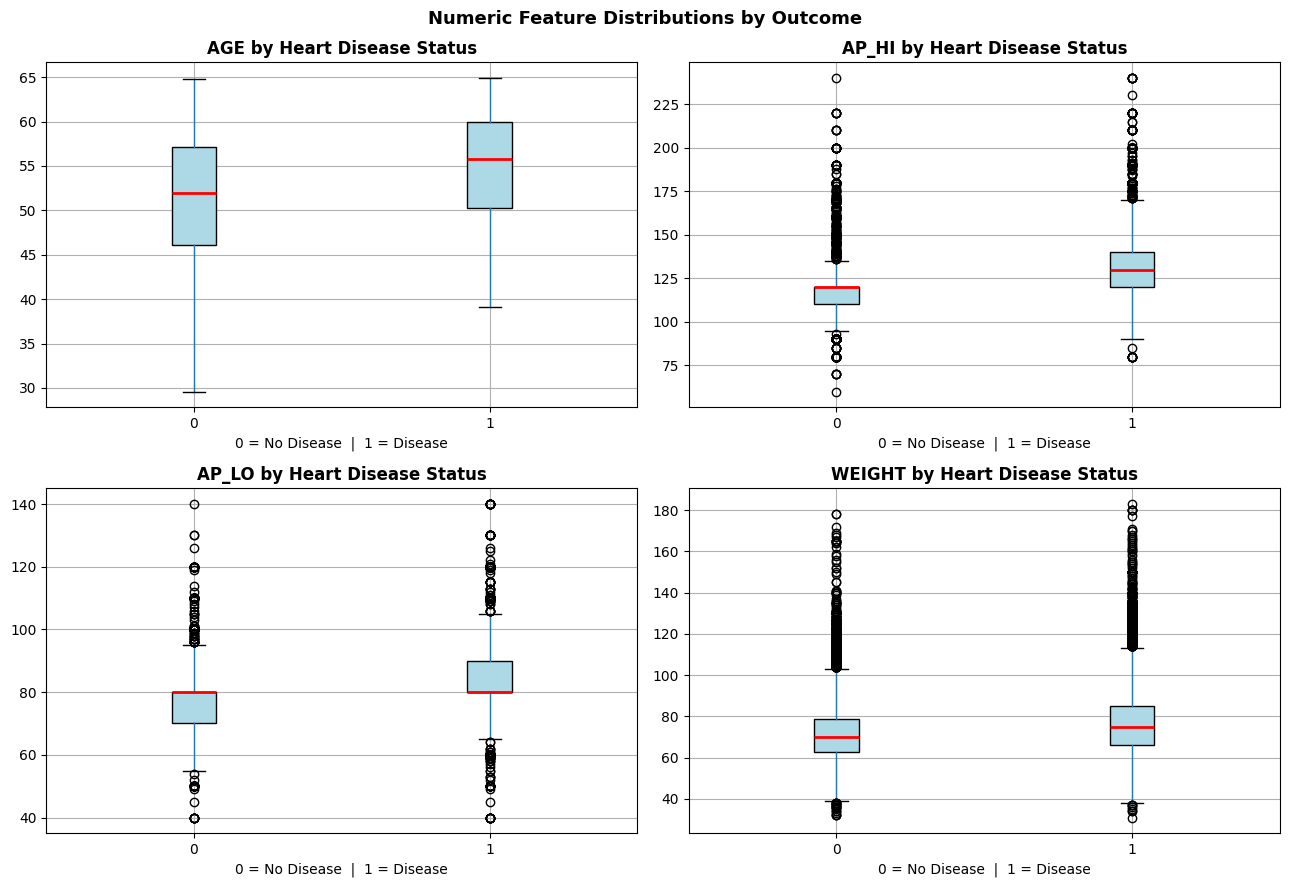

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flatten(), ["age", "ap_hi", "ap_lo", "weight"]):
    df.boxplot(column=col, by="cardio", ax=ax, patch_artist=True,
               boxprops=dict(facecolor="lightblue"),
               medianprops=dict(color="red", linewidth=2))
    ax.set_title(f"{col.upper()} by Heart Disease Status", fontweight="bold")
    ax.set_xlabel("0 = No Disease  |  1 = Disease")
plt.suptitle("Numeric Feature Distributions by Outcome", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## Step 6 — Define Features, Split & Scale
- **X** = all columns except `cardio`  
- **y** = `cardio` (0=healthy, 1=disease)  
- **80/20 split** with `stratify=y` to keep class ratio equal in both splits  
- **StandardScaler** fitted ONLY on training data — prevents data leakage

In [16]:
X = df.drop("cardio", axis=1)
y = df["cardio"]

print(f"Features ({X.shape[1]}): {list(X.columns)}")
print(f"Target: 0={sum(y==0):,}  1={sum(y==1):,}")

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTrain: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

# Scale — fit on train only to avoid leakage
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Save scaler for Streamlit app
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(X.columns), "feature_names.pkl")
print("Scaler saved! (scaler.pkl)")

Features (12): ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi']
Target: 0=34,676  1=33,950

Train: 54,900 | Test: 13,726
Scaler saved! (scaler.pkl)


## Step 7 — Train All 5 Models with GridSearchCV
`GridSearchCV` tests every hyperparameter combination using **5-fold cross-validation**.  
This finds the optimal settings for each model automatically.




In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
trained_models = {}

# ── 1. Logistic Regression ──────────────────────────────────
print("[1/5] Logistic Regression ...", flush=True)
t0 = time.time()
lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=500),
    {"C": [0.1, 1, 10], "solver": ["lbfgs"]},
    cv=cv, scoring="roc_auc", n_jobs=-1
)
lr_grid.fit(X_train_s, y_train)
trained_models["Logistic Regression"] = lr_grid.best_estimator_
print(f"  Done {time.time()-t0:.0f}s | Best: {lr_grid.best_params_} | CV AUC: {lr_grid.best_score_:.4f}")

# ── 2. Decision Tree ────────────────────────────────────────
print("[2/5] Decision Tree ...", flush=True)
t0 = time.time()
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {"max_depth": [5, 10, 15], "min_samples_split": [2, 5], "criterion": ["gini", "entropy"]},
    cv=cv, scoring="roc_auc", n_jobs=-1
)
dt_grid.fit(X_train_s, y_train)
trained_models["Decision Tree"] = dt_grid.best_estimator_
print(f"  Done {time.time()-t0:.0f}s | Best: {dt_grid.best_params_} | CV AUC: {dt_grid.best_score_:.4f}")

# ── 3. Random Forest ────────────────────────────────────────
print("[3/5] Random Forest (slowest ~8 min) ...", flush=True)
t0 = time.time()
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    {"n_estimators": [100, 200], "max_depth": [10, 15], "min_samples_split": [2, 5]},
    cv=cv, scoring="roc_auc", n_jobs=-1
)
rf_grid.fit(X_train_s, y_train)
trained_models["Random Forest"] = rf_grid.best_estimator_
print(f"  Done {time.time()-t0:.0f}s | Best: {rf_grid.best_params_} | CV AUC: {rf_grid.best_score_:.4f}")

# ── 4. SVM on 10K sample (full dataset would take hours) ────
print("[4/5] SVM on 10K sample ...", flush=True)
t0 = time.time()
idx = np.random.RandomState(42).choice(len(X_train_s), size=10000, replace=False)
svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    {"C": [1, 10], "kernel": ["rbf"]},
    cv=StratifiedKFold(3), scoring="roc_auc", n_jobs=-1
)
svm_grid.fit(X_train_s[idx], y_train.iloc[idx])
trained_models["SVM"] = svm_grid.best_estimator_
print(f"  Done {time.time()-t0:.0f}s | Best: {svm_grid.best_params_} | CV AUC: {svm_grid.best_score_:.4f}")

# ── 5. XGBoost ──────────────────────────────────────────────
print("[5/5] XGBoost ...", flush=True)
t0 = time.time()
xgb_grid = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42, n_jobs=-1),
    {"n_estimators": [100, 200], "max_depth": [3, 5],
     "learning_rate": [0.1, 0.2], "subsample": [0.8, 1.0]},
    cv=cv, scoring="roc_auc", n_jobs=1
)
xgb_grid.fit(X_train_s, y_train)
trained_models["XGBoost"] = xgb_grid.best_estimator_
print(f"  Done {time.time()-t0:.0f}s | Best: {xgb_grid.best_params_} | CV AUC: {xgb_grid.best_score_:.4f}")

print("\nAll 5 models trained!")

[1/5] Logistic Regression ...
  Done 3s | Best: {'C': 0.1, 'solver': 'lbfgs'} | CV AUC: 0.7911
[2/5] Decision Tree ...
  Done 2s | Best: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2} | CV AUC: 0.7907
[3/5] Random Forest (slowest ~8 min) ...
  Done 50s | Best: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200} | CV AUC: 0.8005
[4/5] SVM on 10K sample ...
  Done 36s | Best: {'C': 1, 'kernel': 'rbf'} | CV AUC: 0.7859
[5/5] XGBoost ...
  Done 19s | Best: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0} | CV AUC: 0.8016

All 5 models trained!


## Step 8 — 5-Fold Cross-Validation Accuracy
Reports **mean accuracy ± standard deviation** across the 5 folds — a reliable estimate of generalisation performance.

In [18]:
print("5-Fold CV Accuracy Results:")
print("-" * 55)
cv_results = {}
for name, model in trained_models.items():
    scores = cross_val_score(model, X_train_s, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name:<22} Mean={scores.mean():.4f}  Std={scores.std():.4f}")
print("-" * 55)

5-Fold CV Accuracy Results:
-------------------------------------------------------
  Logistic Regression    Mean=0.7278  Std=0.0015
  Decision Tree          Mean=0.7314  Std=0.0033
  Random Forest          Mean=0.7354  Std=0.0033
  SVM                    Mean=0.7332  Std=0.0024
  XGBoost                Mean=0.7358  Std=0.0022
-------------------------------------------------------


## Step 9 — Evaluation Metrics on Test Set
| Metric | Clinical Meaning |
|--------|-----------------|
| **Accuracy** | Overall correctness |
| **Precision** | Of those flagged as disease, how many actually have it |
| **Recall** | Of all actual disease patients, how many did we catch |
| **F1 Score** | Balance between Precision and Recall |
| **ROC-AUC** | Overall discrimination ability |

> **Recall** is most critical in healthcare — missing a diagnosis (False Negative) is more dangerous than a false alarm.

In [19]:
predictions   = {}
probabilities = {}
results = []

for name, model in trained_models.items():
    predictions[name]   = model.predict(X_test_s)
    probabilities[name] = model.predict_proba(X_test_s)[:, 1]
    yp = predictions[name]
    yb = probabilities[name]
    results.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, yp),  4),
        "Precision": round(precision_score(y_test, yp), 4),
        "Recall":    round(recall_score(y_test, yp),    4),
        "F1 Score":  round(f1_score(y_test, yp),        4),
        "ROC-AUC":   round(roc_auc_score(y_test, yb),   4),
    })

results_df = pd.DataFrame(results).set_index("Model")

# Styled table — green = best, red = worst per column
results_df.style.highlight_max(color="lightgreen").highlight_min(color="#ffcccc")

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.723200,0.748500,0.663500,0.703400,0.791300
Decision Tree,0.728800,0.754200,0.670300,0.709800,0.789400
Random Forest,0.731600,0.753800,0.679200,0.714600,0.798900
SVM,0.730500,0.749200,0.684400,0.715300,0.787800
XGBoost,0.733100,0.753200,0.684700,0.717300,0.799600


## Step 10 — Confusion Matrices
```
              Predicted
              No    Yes
Actual No  [ TN  |  FP ]
Actual Yes [ FN  |  TP ]
```
- **FN (False Negative)**: Most dangerous — sick patient told they are healthy  
- **FP (False Positive)**: Healthy patient flagged — causes unnecessary worry

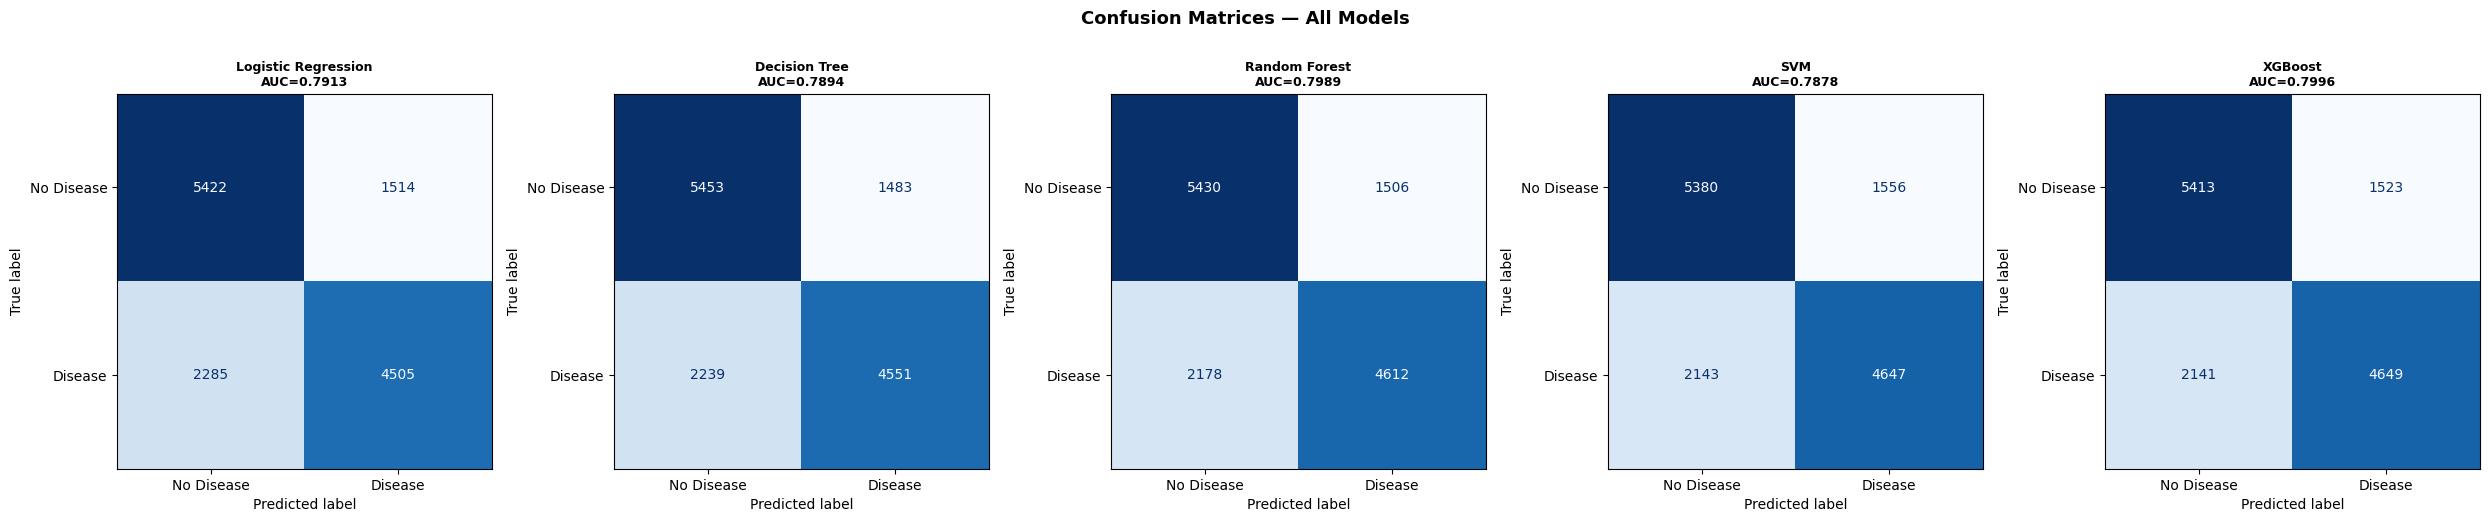

In [20]:
n = len(trained_models)
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
colours_list = ["#3498db","#e74c3c","#2ecc71","#9b59b6","#f39c12"]
for ax, (name, model) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_test, predictions[name])
    ConfusionMatrixDisplay(cm, display_labels=["No Disease","Disease"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\nAUC={results_df.loc[name,'ROC-AUC']}", fontsize=9, fontweight="bold")
plt.suptitle("Confusion Matrices — All Models", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

## Step 11 — ROC Curves
- **AUC = 1.0** → Perfect classifier  
- **AUC = 0.5** → Random guessing (the diagonal line)  
- Higher AUC = better ability to separate disease from no disease at any threshold

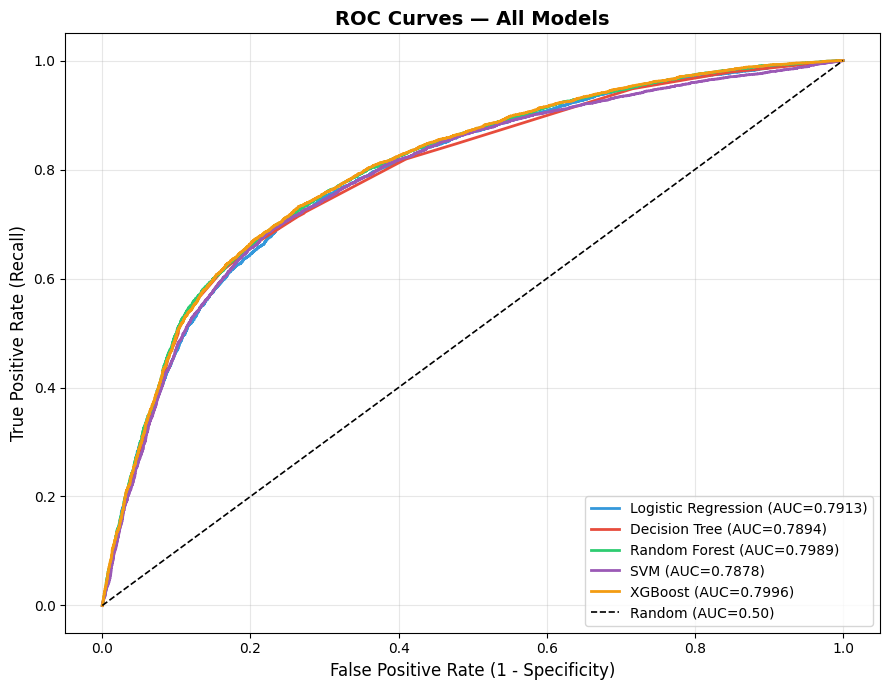

In [21]:
colours_list = ["#3498db","#e74c3c","#2ecc71","#9b59b6","#f39c12"]
plt.figure(figsize=(9, 7))
for (name, _), colour in zip(trained_models.items(), colours_list):
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, color=colour, linewidth=2, label=f"{name} (AUC={auc:.4f})")
plt.plot([0,1],[0,1],"k--", linewidth=1.2, label="Random (AUC=0.50)")
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Recall)", fontsize=12)
plt.title("ROC Curves — All Models", fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Step 12 — Feature Importance
- **Random Forest**: average reduction in Gini impurity across all trees  
- **XGBoost**: fraction of splits using each feature (gain-based)  

These plots validate clinical knowledge — age and blood pressure should rank highest as they are the strongest known risk factors.  
Include these in your dissertation's **Discussion** section.

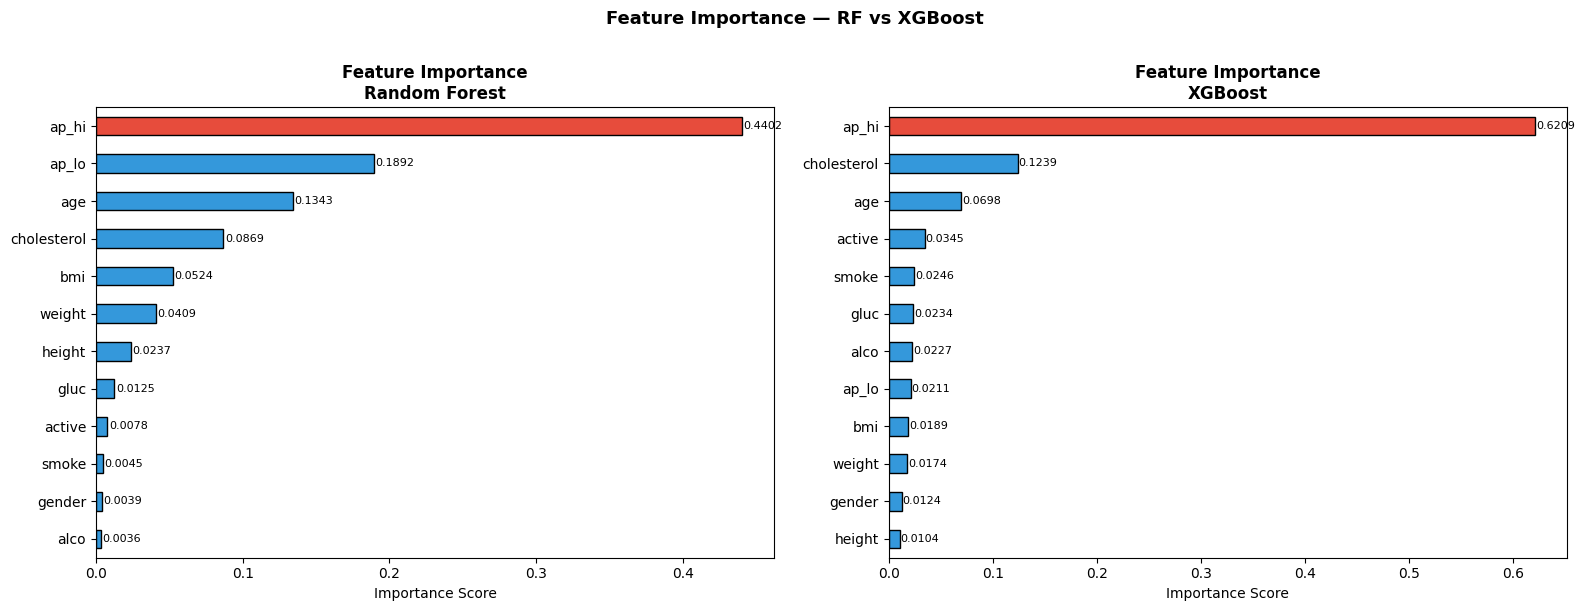

In [22]:
fi_models = [(nm, m) for nm, m in trained_models.items()
             if nm in ("Random Forest", "XGBoost") and hasattr(m, "feature_importances_")]

fig, axes = plt.subplots(1, len(fi_models), figsize=(8*len(fi_models), 6))
if len(fi_models) == 1: axes = [axes]

for ax, (nm, model) in zip(axes, fi_models):
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
    colours_bar = ["#e74c3c" if v == imp.max() else "#3498db" for v in imp]
    imp.plot(kind="barh", ax=ax, color=colours_bar, edgecolor="black")
    ax.set_title(f"Feature Importance\n{nm}", fontweight="bold")
    ax.set_xlabel("Importance Score")
    for i, (val, feat) in enumerate(zip(imp.values, imp.index)):
        ax.text(val + 0.001, i, f"{val:.4f}", va="center", fontsize=8)

plt.suptitle("Feature Importance — RF vs XGBoost", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

## Step 13 — Model Comparison Chart
A grouped bar chart comparing all 5 metrics across all models — ideal for your dissertation Results section.

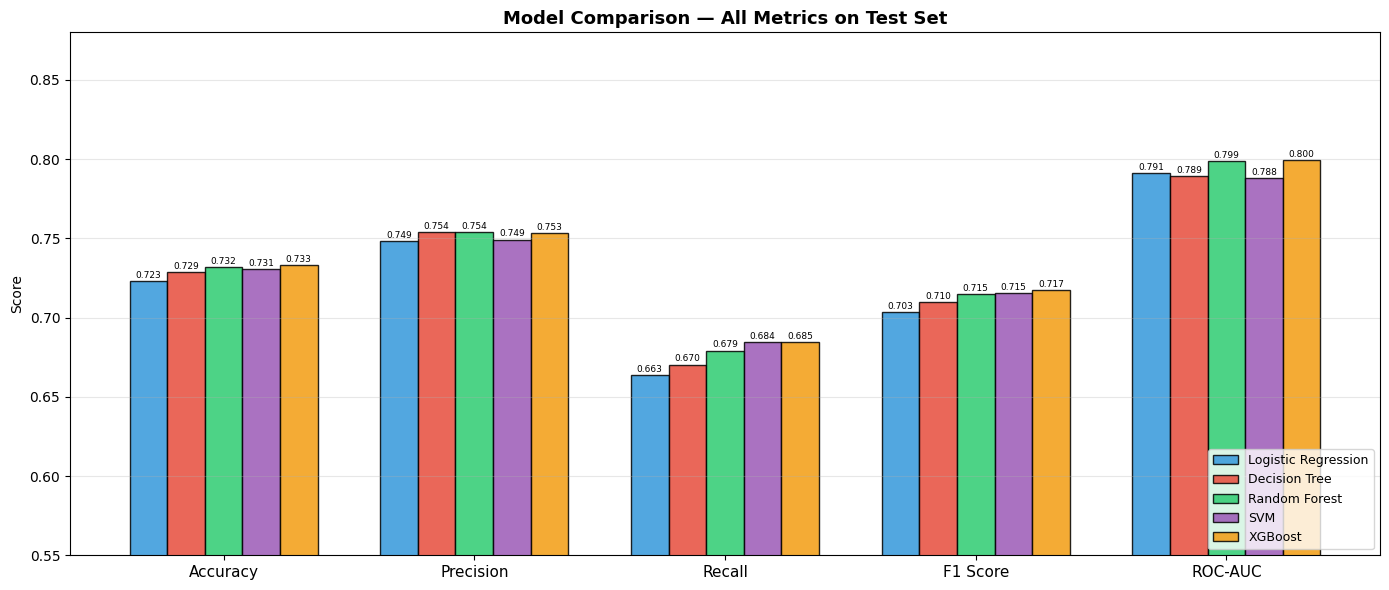

In [23]:
metrics_list = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
model_names  = results_df.index.tolist()
colours_list = ["#3498db","#e74c3c","#2ecc71","#9b59b6","#f39c12"]
x = np.arange(len(metrics_list)); width = 0.15

fig, ax = plt.subplots(figsize=(14, 6))
for i, (nm, colour) in enumerate(zip(model_names, colours_list)):
    vals = [results_df.loc[nm, m] for m in metrics_list]
    bars = ax.bar(x + i*width, vals, width, label=nm, color=colour, edgecolor="black", alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f"{val:.3f}", ha="center", fontsize=6.5)

ax.set_xticks(x + width*(len(model_names)-1)/2)
ax.set_xticklabels(metrics_list, fontsize=11)
ax.set_ylim(0.55, 0.88); ax.set_ylabel("Score")
ax.set_title("Model Comparison — All Metrics on Test Set", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Step 14 — Cross-Validation Stability
A **narrow boxplot** = consistent model across folds (low variance = more trustworthy).  
A **wide boxplot** = performance varies — model may be overfitting to certain data patterns.

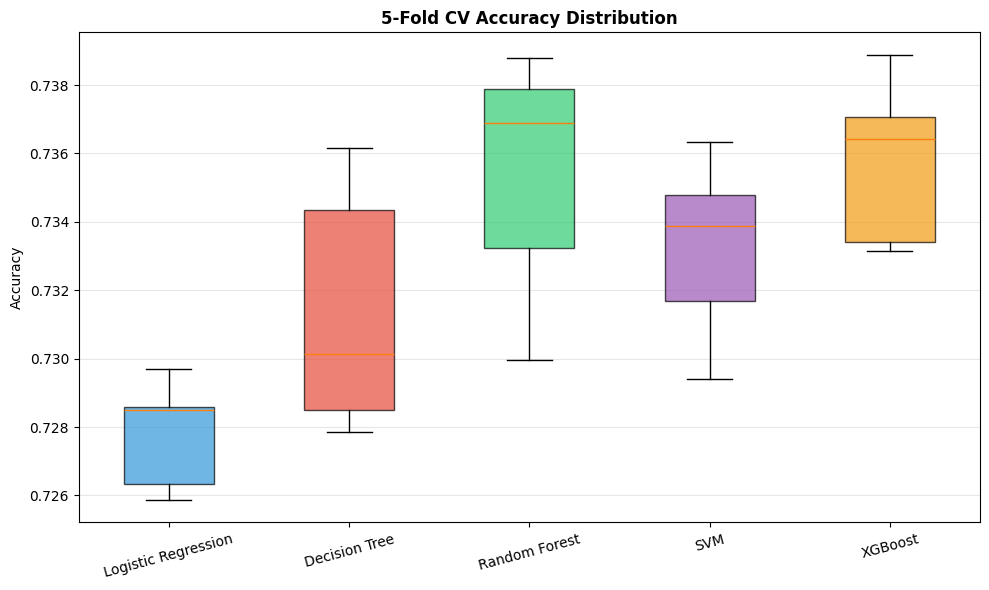

In [24]:
colours_list = ["#3498db","#e74c3c","#2ecc71","#9b59b6","#f39c12"]
fig, ax = plt.subplots(figsize=(10, 6))
cv_data = [cv_results[nm] for nm in cv_results]
bp = ax.boxplot(cv_data, labels=cv_results.keys(), patch_artist=True)
for patch, colour in zip(bp["boxes"], colours_list):
    patch.set_facecolor(colour); patch.set_alpha(0.7)
ax.set_title("5-Fold CV Accuracy Distribution", fontsize=12, fontweight="bold")
ax.set_ylabel("Accuracy"); ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

## Step 15 — Detailed Classification Report
The full per-class breakdown — useful for your dissertation Appendix.

In [25]:
best_name = results_df["ROC-AUC"].idxmax()
print(f"Best model by ROC-AUC: {best_name}  ({results_df['ROC-AUC'].max():.4f})")
print("=" * 55)
print(classification_report(y_test, predictions[best_name],
                             target_names=["No Heart Disease", "Heart Disease"]))

Best model by ROC-AUC: XGBoost  (0.7996)
                  precision    recall  f1-score   support

No Heart Disease       0.72      0.78      0.75      6936
   Heart Disease       0.75      0.68      0.72      6790

        accuracy                           0.73     13726
       macro avg       0.73      0.73      0.73     13726
    weighted avg       0.73      0.73      0.73     13726



## Step 16 — Save & Download Model Files
These 3 files are needed to run the **Streamlit web app**.  
They will download automatically to your computer.

In [27]:
from google.colab import files

# Save the best model
best_model = trained_models[best_name]
joblib.dump(best_model, "best_model.pkl")
print(f"Saved best_model.pkl ({best_name})")

# Download all 3 files
print("\nDownloading files to your computer...")
files.download("best_model.pkl")
files.download("scaler.pkl")
files.download("feature_names.pkl")

print("\n" + "="*55)
print("FINAL RESULTS SUMMARY")
print("="*55)
print(results_df.to_string())
print(f"\nBest Model    : {best_name}")
print(f"Best ROC-AUC  : {results_df['ROC-AUC'].max():.4f}")
print(f"Best Accuracy : {results_df['Accuracy'].max():.4f}")
print("="*55)
print("\nDone! Now place the 3 .pkl files next to app.py and run:")
print("  streamlit run app.py")

Saved best_model.pkl (XGBoost)



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


FINAL RESULTS SUMMARY
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.7232     0.7485  0.6635    0.7034   0.7913
Decision Tree          0.7288     0.7542  0.6703    0.7098   0.7894
Random Forest          0.7316     0.7538  0.6792    0.7146   0.7989
SVM                    0.7305     0.7492  0.6844    0.7153   0.7878
XGBoost                0.7331     0.7532  0.6847    0.7173   0.7996

Best Model    : XGBoost
Best ROC-AUC  : 0.7996
Best Accuracy : 0.7331

Done! Now place the 3 .pkl files next to app.py and run:
  streamlit run app.py
